In [2]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1)	Abrir as imagens coloridas e mostrar a imagem e seus histogramas (separados) cada canal de cor. Considerar os seguintes sistemas de cores:
a.	RGB
b.	HSV ou HSI
c.	Lab


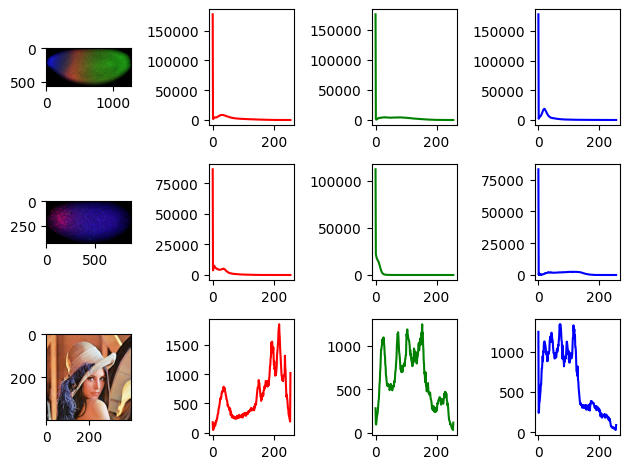

In [30]:
plot_colors = ["red","green","blue"]

img1 = cv2.imread("image.jpg", cv2.IMREAD_COLOR)
img1RGB = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 1)
plt.imshow(img1RGB)

for i, color in enumerate(plot_colors):
    hist = cv2.calcHist([img1RGB], [i], None, [256], [0, 256])
    plt.subplot(3, 4, i + 2)
    plt.plot(hist, color=color)
    

img2 = cv2.imread("image2.jpg", cv2.IMREAD_COLOR)
img2RGB = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 5)
plt.imshow(img2RGB)

for i, color in enumerate(plot_colors):
    hist = cv2.calcHist([img2RGB], [i], None, [256], [0, 256])
    plt.subplot(3, 4, i + 6)
    plt.plot(hist, color=color)

img3 = cv2.imread("Lenna.jpg", cv2.IMREAD_COLOR)
img3RGB = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 9)
plt.imshow(img3RGB)

for i, color in enumerate(plot_colors):
    hist = cv2.calcHist([img3RGB], [i], None, [256], [0, 256])
    plt.subplot(3, 4, i + 10)
    plt.plot(hist, color=color)

plt.tight_layout()
plt.show()

2)	Utilizando a imagem do mandrill, faça rotinas para detecção do focinho (região vermelha e azul). Utilize algum algoritmo de limiarização.

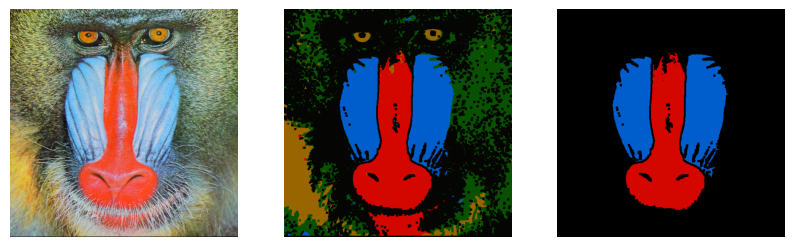

In [41]:
img_mand = cv2.imread("mandrill.tiff", cv2.IMREAD_COLOR)
img_mand_RGB = cv2.cvtColor(img_mand, cv2.COLOR_BGR2RGB)

def saturate_max_bgr(bgr: np.ndarray) -> np.ndarray:
    #S = 255 (máximo)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hsv[..., 1] = 255
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def quantize_k_colors(bgr: np.ndarray, k: int = 5, attempts: int = 3) -> np.ndarray:
    Z = bgr.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1.0)
    _, labels, centers = cv2.kmeans(Z, k, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)
    centers = np.uint8(centers)
    quant = centers[labels.flatten()].reshape(bgr.shape)
    return quant

hsv_max_sat = saturate_max_bgr(img_mand_RGB)
#erosão
kernel = np.ones((5, 5), np.uint8)
hsv_eroded = cv2.erode(hsv_max_sat, kernel, iterations=1)
hsv_max_sat_quant = quantize_k_colors(hsv_eroded, 5)

# alvos para selecionar, selecionar os maior os 3 maiores tava pegando uma parte dos pelos do bicho

h, w = hsv_max_sat_quant.shape[:2]
componentes = []

# percorrer cada cor por componmente conexo
cores_unicas = np.unique(hsv_max_sat_quant.reshape(-1, 3), axis=0)

for cor in cores_unicas:
    mask = np.all(hsv_max_sat_quant == cor, axis=2).astype(np.uint8)
    # vizinhança 8
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    for i in range(1, n_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        componentes.append((area, labels == i, cor))

componentes.sort(key=lambda x: x[0], reverse=True)
focinho = []
focinho.append(componentes[1])
focinho.append(componentes[3])
focinho.append(componentes[4])

saida = np.zeros_like(hsv_max_sat_quant)

for area, comp_mask, cor in focinho:
    saida[comp_mask] = cor


plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_mand_RGB)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hsv_max_sat_quant)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(saida)
plt.axis("off")

plt.show()



3)	Utilizando a imagem HE.jpg, tente detectar e contar a quantidade de núcleos celulares (em azul). Aplicar o Ostu para os 9 canais de cores e avaliar qual foi melhor (R,G,B,H,S,V,L,a,b)

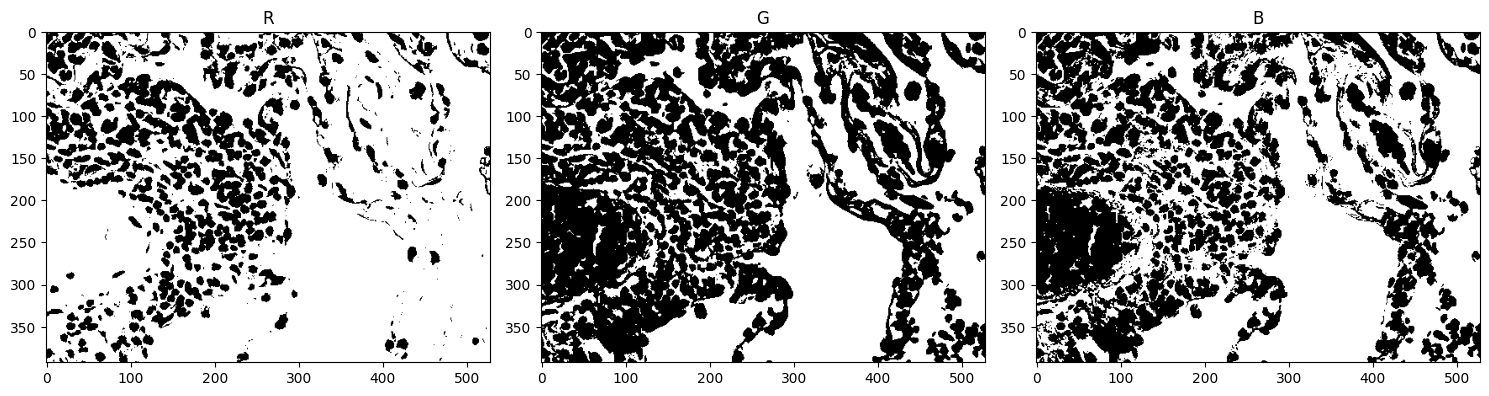

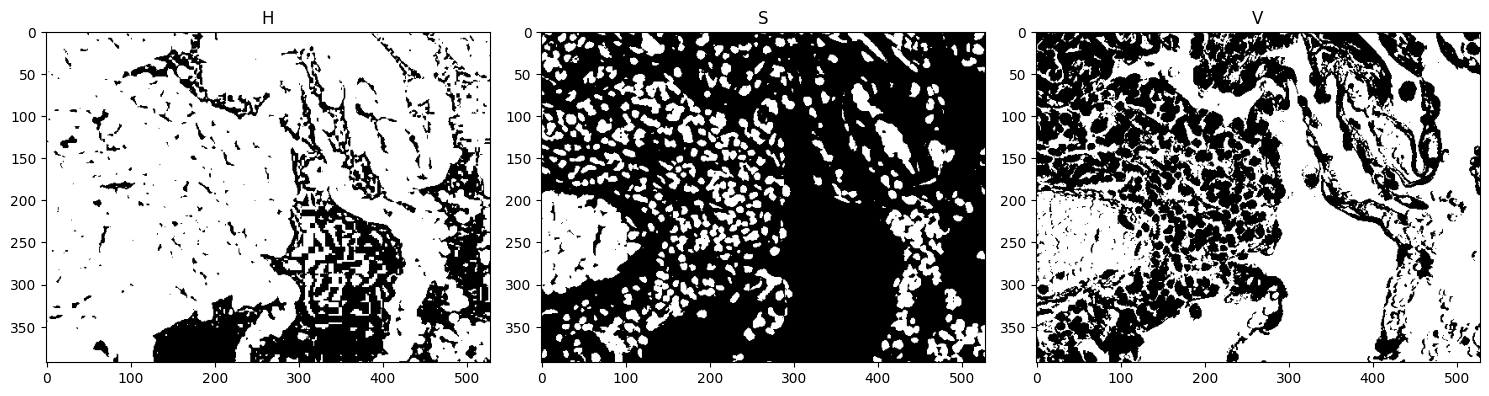

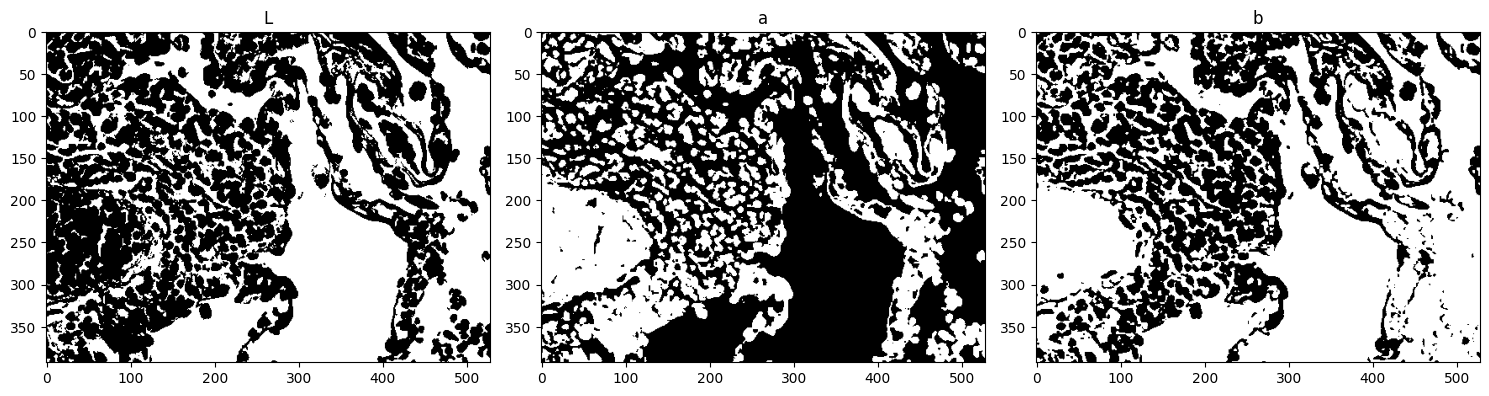

In [65]:
img_he = cv2.imread("HE.jpg", cv2.IMREAD_COLOR)

# RGB
img_he_RGB = cv2.cvtColor(img_he, cv2.COLOR_BGR2RGB)
R = img_he_RGB[:, :, 0]
G = img_he_RGB[:, :, 1]
B = img_he_RGB[:, :, 2]

#otsu
_, otsu_R = cv2.threshold(R, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_G = cv2.threshold(G, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_B = cv2.threshold(B, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(otsu_R, cmap='gray')
plt.title("R")

plt.subplot(1, 3, 2)
plt.imshow(otsu_G, cmap='gray')
plt.title("G")

plt.subplot(1, 3, 3)
plt.imshow(otsu_B, cmap='gray')
plt.title("B")

plt.tight_layout()
plt.show()

# HSV
img_he_HSV = cv2.cvtColor(img_he_RGB, cv2.COLOR_RGB2HSV)
H = img_he_HSV[:, :, 0]
S = img_he_HSV[:, :, 1]
V = img_he_HSV[:, :, 2]

#otsu
_, otsu_H = cv2.threshold(H, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_S = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_V = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(otsu_H, cmap='gray')
plt.title("H")

plt.subplot(1, 3, 2)
plt.imshow(otsu_S, cmap='gray')
plt.title("S")

plt.subplot(1, 3, 3)
plt.imshow(otsu_V, cmap='gray')
plt.title("V")

plt.tight_layout()
plt.show()


# LAB
img_he_LAB = cv2.cvtColor(img_he_RGB, cv2.COLOR_RGB2LAB)

L = img_he_LAB[:, :, 0]
a = img_he_LAB[:, :, 1]
b = img_he_LAB[:, :, 2]

_, otsu_L = cv2.threshold(L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_a = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_b = cv2.threshold(b, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(otsu_L, cmap="gray")
plt.title("L")

plt.subplot(1, 3, 2)
plt.imshow(otsu_a, cmap="gray")
plt.title("a")

plt.subplot(1, 3, 3)
plt.imshow(otsu_b, cmap="gray")
plt.title("b")

plt.tight_layout()
plt.show()

Quantidade de núcleos após watershed: 288


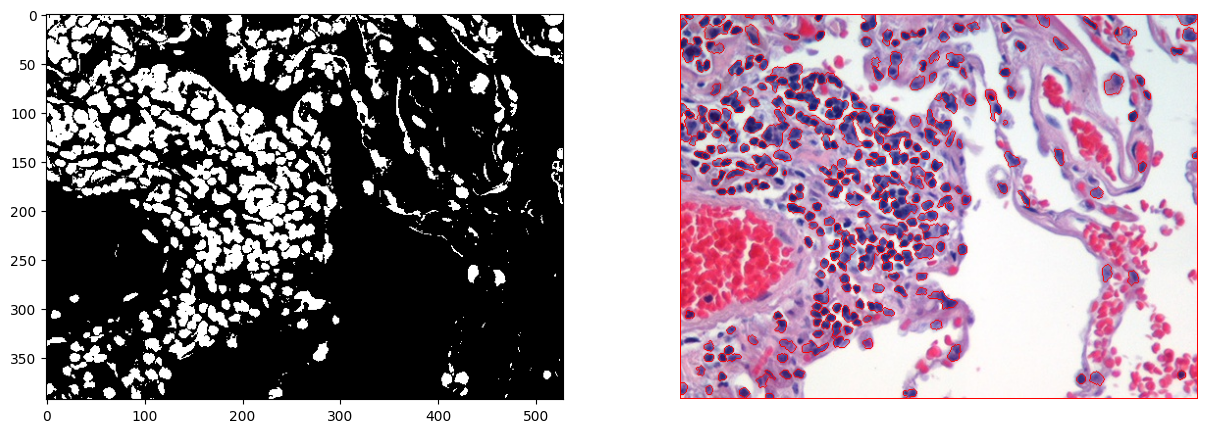

In [70]:
mask = (otsu_R == 0).astype(np.uint8)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
sure_bg = cv2.dilate(opening, kernel, iterations=2)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 1.0, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
n_labels, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 1] = 0
# passando pra rgb pra fazer o watersehd
img_ws = img_he_RGB.copy()
img_ws_bgr = cv2.cvtColor(img_ws, cv2.COLOR_RGB2BGR)

markers = cv2.watershed(img_ws_bgr, markers)
resultado = img_he_RGB.copy()
resultado[markers == -1] = [255, 0, 0]  # borda em vermelho

total = len(np.unique(markers)) - 2  # remove borda (-1 não entra no unique positivo) e fundo 1
labels_validos = [x for x in np.unique(markers) if x > 1]

print("Quantidade de núcleos após watershed:", len(labels_validos))

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")

plt.subplot(1, 2, 2)
plt.imshow(resultado)
plt.axis("off")

plt.show()